In [1]:
from pathlib import Path 
import math
import random
import random
import math

class Env:

    def __init__(self, input_txt_path: Path):
        self.W, self.D, self.N, self.a = self._input(input_txt_path)

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        W, D, N = map(int, lines[0].split())
        a = []
        for line, d in zip(lines[1:], range(D)):
            d = list(map(int, line.split()))
            a.append(d)
        return W, D, N, a

In [2]:
class Rect:
    def __init__(self, x, y, w, h):
        self.x1 = x
        self.y1 = y
        self.x2 = x + w
        self.y2 = y + h
        self.w = w
        self.h = h

    def overlap(self, b: "Rect"):
        return max(self.x1, b.x1) < min(self.x2, b.x2) and max(self.y1, b.y1) < min(self.y2, b.y2)

    def subtract_by(self, b: "Rect"):
        if self.overlap(b):
            rooms = []
            if (self.x1 < b.x1 and b.x1 < self.x2) and max(self.y1, b.y1) < min(self.y2, b.y2):
                rooms.append(Rect(self.x1, self.y1, b.x1 - self.x1, self.h))

            if (self.x1 < b.x2 and b.x2 < self.x2) and max(self.y1, b.y1) < min(self.y2, b.y2):
                rooms.append(Rect(b.x2, self.y1, self.x2 - b.x2, self.h))

            if (self.y1 < b.y1 and b.y1 < self.y2) and max(self.x1, b.x1) < min(self.x2, b.x2):
                rooms.append(Rect(self.x1, self.y1, self.w, b.y1 - self.y1))

            if (self.y1 < b.y2 and b.y2 < self.y2) and max(self.x1, b.x1) < min(self.x2, b.x2):
                rooms.append(Rect(self.x1, b.y2, self.w, self.y2 - b.y2))
            return rooms

        else:
            return [self]

    def include(self, b:"Rect"):
        return self.x1 <= b.x1 and b.x2 <= self.x2 and self.y1 <= b.y1 and b.y2 <= self.y2

    def larger_than(self, w, h):
        # 座標は関係なく、図形として入るかどうか
        return w <= self.w and h <= self.h

    def __str__(self):
        return "({}, {}, {}, {})".format(self.x1, self.y1, self.w, self.h)

class MyRectangle:
    def __init__(self, area, width, height, min_len, max_len):
        self.area = area
        self.width = width
        self.height = height
        self.min_len = min_len
        self.max_len = max_len

    def random_resize(self):
        change_len = max(0, int(self.area ** 0.5 * 0.2))
        if random.random() < 0.5:
            next_w = random.randint(max(self.min_len, self.width - change_len), min(self.max_len, self.width + change_len))
            next_h = math.ceil(self.area / next_w)
        else:
            next_h = random.randint(max(self.min_len, self.height - change_len), min(self.max_len, self.height + change_len))
            next_w = math.ceil(self.area / next_h)            
        self.width = next_w
        self.height = next_h

    def __str__(self):
        return f"Rectangle({self.width}, {self.height})"

In [11]:
def put_rect(input_rects, roomsORIG=[Rect(0, 0, 1024, 10000)]):

    # 空白矩形と比較し、配置可能な空白を探索
    rects : list[Rect] = []
    not_rects : list[Rect] = []
    uniq_rooms: list[Rect] = list(roomsORIG)
    cost = 0

    for input_rect in input_rects:

        is_ok = False
        for i in range(len(uniq_rooms)):
            room = uniq_rooms[i]
            if room.larger_than(input_rect[0], input_rect[1]):  # このrectに配置可能
                new_rect = Rect(room.x1, room.y1, input_rect[0], input_rect[1])
                rects.append(new_rect)
                is_ok = True
                break

        if is_ok:
            # すべての空白矩形から subtractする
            new_rooms: list[Rect] = []
            for room in uniq_rooms:
                new_rooms += room.subtract_by(new_rect)
            new_rooms = sorted(new_rooms, key=lambda x: x.y1)  # 結局総当たりするので意味ないが、将来効率化を考えソート

            # 重複削除 総当たり
            uniq_rooms: list[Rect] = []
            for r_i in new_rooms:
                include_flg = False
                for r_j in new_rooms:
                    if r_i == r_j:
                        continue
                    if r_j.include(r_i):
                        include_flg = True
                        break
                if not include_flg:
                    # print("{} は他のどれにも含まれない".format(r_i))
                    uniq_rooms.append(r_i)

            # 低い順（左にある順）に並び替え
            new_rooms = sorted(new_rooms, key=lambda a: a.x1)
            uniq_rooms = sorted(new_rooms, key=lambda a: a.y1)
        else:
            not_rects.append(input_rect)
            cost += input_rect[0] * input_rect[1]

    print(len(new_rooms) + len(uniq_rooms))
    return (cost, rects, not_rects, uniq_rooms)

In [12]:
sample_txt_path = Path("tools/in/0001.txt")
env = Env(sample_txt_path)

In [13]:
rectangles: list[MyRectangle] = []
for area in env.a[0]:
    divs = []
    for div1 in range(1, 1000 + 1):
        div2 = math.ceil(area / div1)
        if 1 <= div1 <= 1000 and 1 <= div2 <= 1000:
            divs.append(div1)
            divs.append(div2)
    min_len = min(divs)
    max_len = max(divs)
    if random.random() < 0.5:
        w = random.randint(min_len, max_len)
        h = math.ceil(area / w)
    else:
        h = random.randint(min_len, max_len)
        w = math.ceil(area / h)
    rectangles.append(MyRectangle(
        area=area,
        width=w,
        height=h,
        min_len=min_len,
        max_len=max_len
    ))
rectangles = sorted(rectangles, key=lambda x: x.height, reverse=True)

In [14]:
from copy import deepcopy
W=1000
INF = 10**18
N = len(rectangles)
best_rectangles = deepcopy(rectangles)

best_x: list[Rect] = []
best_cost = INF
for simulate_n in range(100):

    # 適当な近傍探索
    
    now_rectangles = deepcopy(best_rectangles)
    if random.random() < 1/3:
        i = random.randint(0, N-1)
        shift = random.randint(1, max(1, round(N * 0.2)))
        j = random.randint(max(0, i-shift), min(N-1, i+shift))

        now_rectangles[i], now_rectangles[j] = now_rectangles[j], now_rectangles[i]
    elif random.random() < 1/3:
        i = random.randint(0, N-1)
        now_rectangles[i].random_resize()
    else:
        i = random.randint(0, N-1)
        shift = random.randint(1, max(1, round(N * 0.2)))
        j = random.randint(max(0, i-shift), min(N-1, i+shift))
        now_rectangles[i], now_rectangles[j] = now_rectangles[j], now_rectangles[i]

        now_rectangles[i].random_resize()
        now_rectangles[j].random_resize()
    
    input_rects = [(rect.width, rect.height) for rect in now_rectangles]
    not_place_area, simulated_rects, _, _ =put_rect(input_rects, roomsORIG=[Rect(0, 0, W, W)])
    if not_place_area < best_cost:
        best_cost = not_place_area
        best_rectangles = deepcopy(now_rectangles)
        best_x = simulated_rects

    if simulate_n % 10 == 0:
        print(f"simulate_n {simulate_n}, now_cost: {not_place_area}, best_cost: {best_cost}")

1050
simulate_n 0, now_cost: 155385, best_cost: 155385
1616
1358
1384
1236
1232
1726
2002
1730
826
1682
simulate_n 10, now_cost: 127381, best_cost: 127381
1662
1726
1764
1744
1424
568
2120
1870
2414
1596
simulate_n 20, now_cost: 133534, best_cost: 127073
2120
1204
2120
2102
2256
2308
2716
2728
2528
2152
simulate_n 30, now_cost: 126867, best_cost: 126867
2144
2278
2120
2128
682
2120
1646
1270
2144
1222
simulate_n 40, now_cost: 144866, best_cost: 126867
2120
2120
2120
2834
2250
2646
2120
2120
2120
1664
simulate_n 50, now_cost: 137099, best_cost: 126624
2282
1224
2120
2148
2252
2148
2020
1228
1652
2120
simulate_n 60, now_cost: 126624, best_cost: 126624
2198
3526
732
1464
1228
2940
1676
2160
678
1734
simulate_n 70, now_cost: 126624, best_cost: 126624
2120
948
1726
2152
2232
1216
1216
1320
946
1434
simulate_n 80, now_cost: 115844, best_cost: 115844
1362
1320
1454
1182
1320
1546
1320
1294
1320
1320
simulate_n 90, now_cost: 115589, best_cost: 115589
1708
1258
1232
1690
1216
1142
1878
1056
121

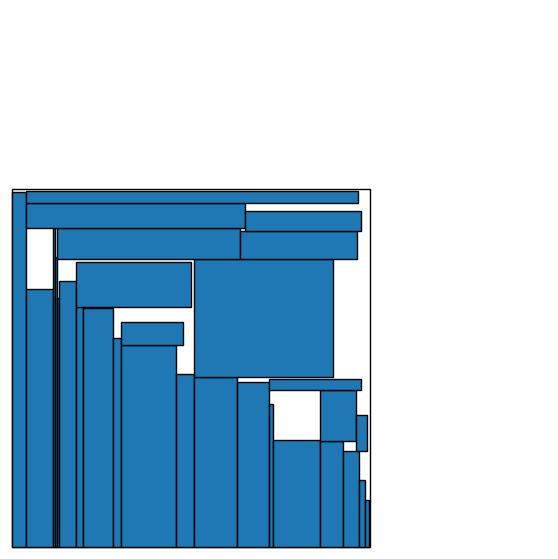

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig = plt.figure(figsize=(7, 7))
ax = plt.axes()

r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
ax.add_patch(r)

for rect in best_x:
    r = patches.Rectangle(xy=(rect.x1, rect.y1), width=rect.w, height=rect.h, ec='#000000', fill=True)
    ax.add_patch(r)

plt.xlim(-5, 1500)
plt.ylim(-5, 1500)
plt.axis('off')
ax.set_aspect('equal')